# Library Install + Import

In [ ]:
#!pip install sentence-transformers umap-learn hdbscan # Installation package ready

import warnings
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import hdbscan
from sentence_transformers import SentenceTransformer
import umap
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
drugs = pd.read_csv('/content/drive/MyDrive/Unsupervised and Unstructured Project/data/drugs.csv')
display(drugs.head(3))
display(drugs.info())

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1988 entries, 0 to 1987
Data columns (total 28 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   category                                     1988 non-null   object 
 1   medicine_name                                1988 non-null   object 
 2   therapeutic_area                             1703 non-null   object 
 3   common_name                                  1984 non-null   object 
 4   active_substance                             1987 non-null   object 
 5   product_number                               1988 non-null   int64  
 6   patient_safety                               1988 non-null   bool   
 7   authorisation_status                         1987 non-null   object 
 8   atc_code                                     1960 non-null   object 
 9   additional_monitoring                        1988 non-null   bool   
 10  

None

# Preprocessing & EDA

In [ ]:
# BioBERT implementation

drugs['condition_indication'] = drugs['condition_indication'].fillna('')

med_transformer = SentenceTransformer('NeuML/pubmedbert-base-embeddings') # Using a transformer specifically pre-trained on medical literature and fine-tuned for sentence embeddings.
X_embeddings = med_transformer.encode(drugs['condition_indication'].tolist(), show_progress_bar=True)

# View / Check Result
print(f"\n--- BioBERT Embedding Result ---")
print(f"Matrix Shape: {X_embeddings.shape} (Rows, Dimensions)")
print(f"Sample Vector (First 5 dimensions of Drug 1): {X_embeddings[0][:5]}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/63 [00:00<?, ?it/s]


--- BioBERT Embedding Result ---
Matrix Shape: (1988, 768) (Rows, Dimensions)
Sample Vector (First 5 dimensions of Drug 1): [ 0.4530915  -0.44275132  0.03415158 -0.24616887 -0.39313212]


--- M4 Text Sequence Length Analysis ---
Max Word Count: 1092
Average Word Count: 70.1
95th Percentile: 226.6
Conclusion: The vast majority of indications fall well under the 512-token limit, ensuring optimal BioBERT encoding.


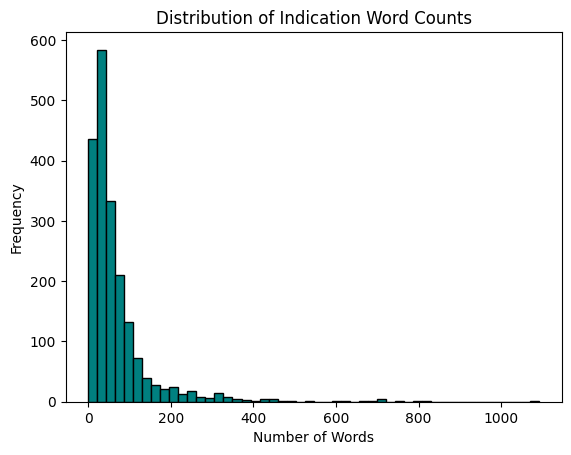

In [ ]:
# Word Count Visualization
drugs['word_count'] = drugs['condition_indication'].apply(lambda x: len(str(x).split()))

print("--- M4 Text Sequence Length Analysis ---")
print(f"Max Word Count: {drugs['word_count'].max()}")
print(f"Average Word Count: {drugs['word_count'].mean():.1f}")
print(f"95th Percentile: {drugs['word_count'].quantile(0.95):.1f}")
print("Conclusion: The vast majority of indications fall well under the 512-token limit, ensuring optimal BioBERT encoding.")

plt.hist(drugs['word_count'], bins=50, color='teal', edgecolor='black')
plt.title("Distribution of Indication Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# UMAP -> HDBSCAN 3D Matrix Transformation

In [ ]:
reducer_cluster = umap.UMAP(n_neighbors=15, n_components=5, metric='cosine', random_state=42)
X_umap_cluster = reducer_cluster.fit_transform(X_embeddings)

reducer_3d = umap.UMAP(n_neighbors=15, n_components=3, metric='cosine', random_state=42)
X_umap_3d = reducer_3d.fit_transform(X_embeddings)

drugs['umap_x'] = X_umap_3d[:, 0]
drugs['umap_y'] = X_umap_3d[:, 1]
drugs['umap_z'] = X_umap_3d[:, 2]

print("\n--- UMAP Result ---")
print(f"Clustering Matrix Shape: {X_umap_cluster.shape}")
print(f"Visualization Matrix Shape: {X_umap_3d.shape}")


--- UMAP Result ---
Clustering Matrix Shape: (1988, 5)
Visualization Matrix Shape: (1988, 3)


In [ ]:
# HDBSCAN initialization and integratino with UMAP clusters

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=15, # Minimum grouping to consider a valid therapeutic area
    min_samples=5,       # Control for clustering (higher = more drugs marked as outliers)
    metric='euclidean'   # We use euclidean here because UMAP already perfectly arranged the cosine geometry
)

drugs['cluster_hdbscan'] = clusterer.fit_predict(X_umap_cluster)
n_clusters = len(set(drugs['cluster_hdbscan'])) - (1 if -1 in drugs['cluster_hdbscan'].values else 0)
n_outliers = list(drugs['cluster_hdbscan']).count(-1)

print(f"\n--- HDBSCAN Discovery ---")
print(f"Total Organic Clusters Found: {n_clusters}")
print(f"Total 'Blue Ocean' Outliers (-1): {n_outliers} drugs")

print("\nCluster Size Distribution (Top 10):")
# -1 will likely be the largest "group", which is perfectly normal for text data!
print(drugs['cluster_hdbscan'].value_counts().head(10))


--- HDBSCAN Discovery ---
Total Organic Clusters Found: 52
Total 'Blue Ocean' Outliers (-1): 228 drugs

Cluster Size Distribution (Top 10):
cluster_hdbscan
-1     228
 13    171
 7      78
 35     74
 1      74
 45     48
 29     47
 5      45
 18     44
 10     40
Name: count, dtype: int64


The following visualization below uses a format not compatible with Github notebook view. Please download the .ipynb file to fully view and explore the 3D visualization.

In [ ]:
!pip install kaleido

In [ ]:
# HDBSCAN Cluster Visualization

drugs['cluster_hdbscan_str'] = drugs['cluster_hdbscan'].astype(str)
color_map = {'-1': 'lightgray'}

drugs['short_indication'] = drugs['condition_indication'].apply(
    lambda x: str(x)[:120] + "..." if len(str(x)) > 120 else str(x)
)

# Generate the Interactive 3D Plot
fig = px.scatter_3d(
    drugs,
    x='umap_x',
    y='umap_y',
    z='umap_z',
    color='cluster_hdbscan_str',
    color_discrete_map=color_map,
    hover_name='medicine_name',
    hover_data={
        'short_indication': True,
        'cluster_hdbscan_str': False, # Hide the string version
        'cluster_hdbscan': True,      # Show the actual number
        'umap_x': False,
        'umap_y': False,
        'umap_z': False
    },
    title='M4 Refinement: BioBERT + UMAP Semantic Landscape'
)

# Styling to make it readable
fig.update_traces(marker=dict(size=4, opacity=0.8, line=dict(width=0)))
fig.update_layout(legend_title_text='Cluster ID ( -1 = Outliers )')

# fig.show()

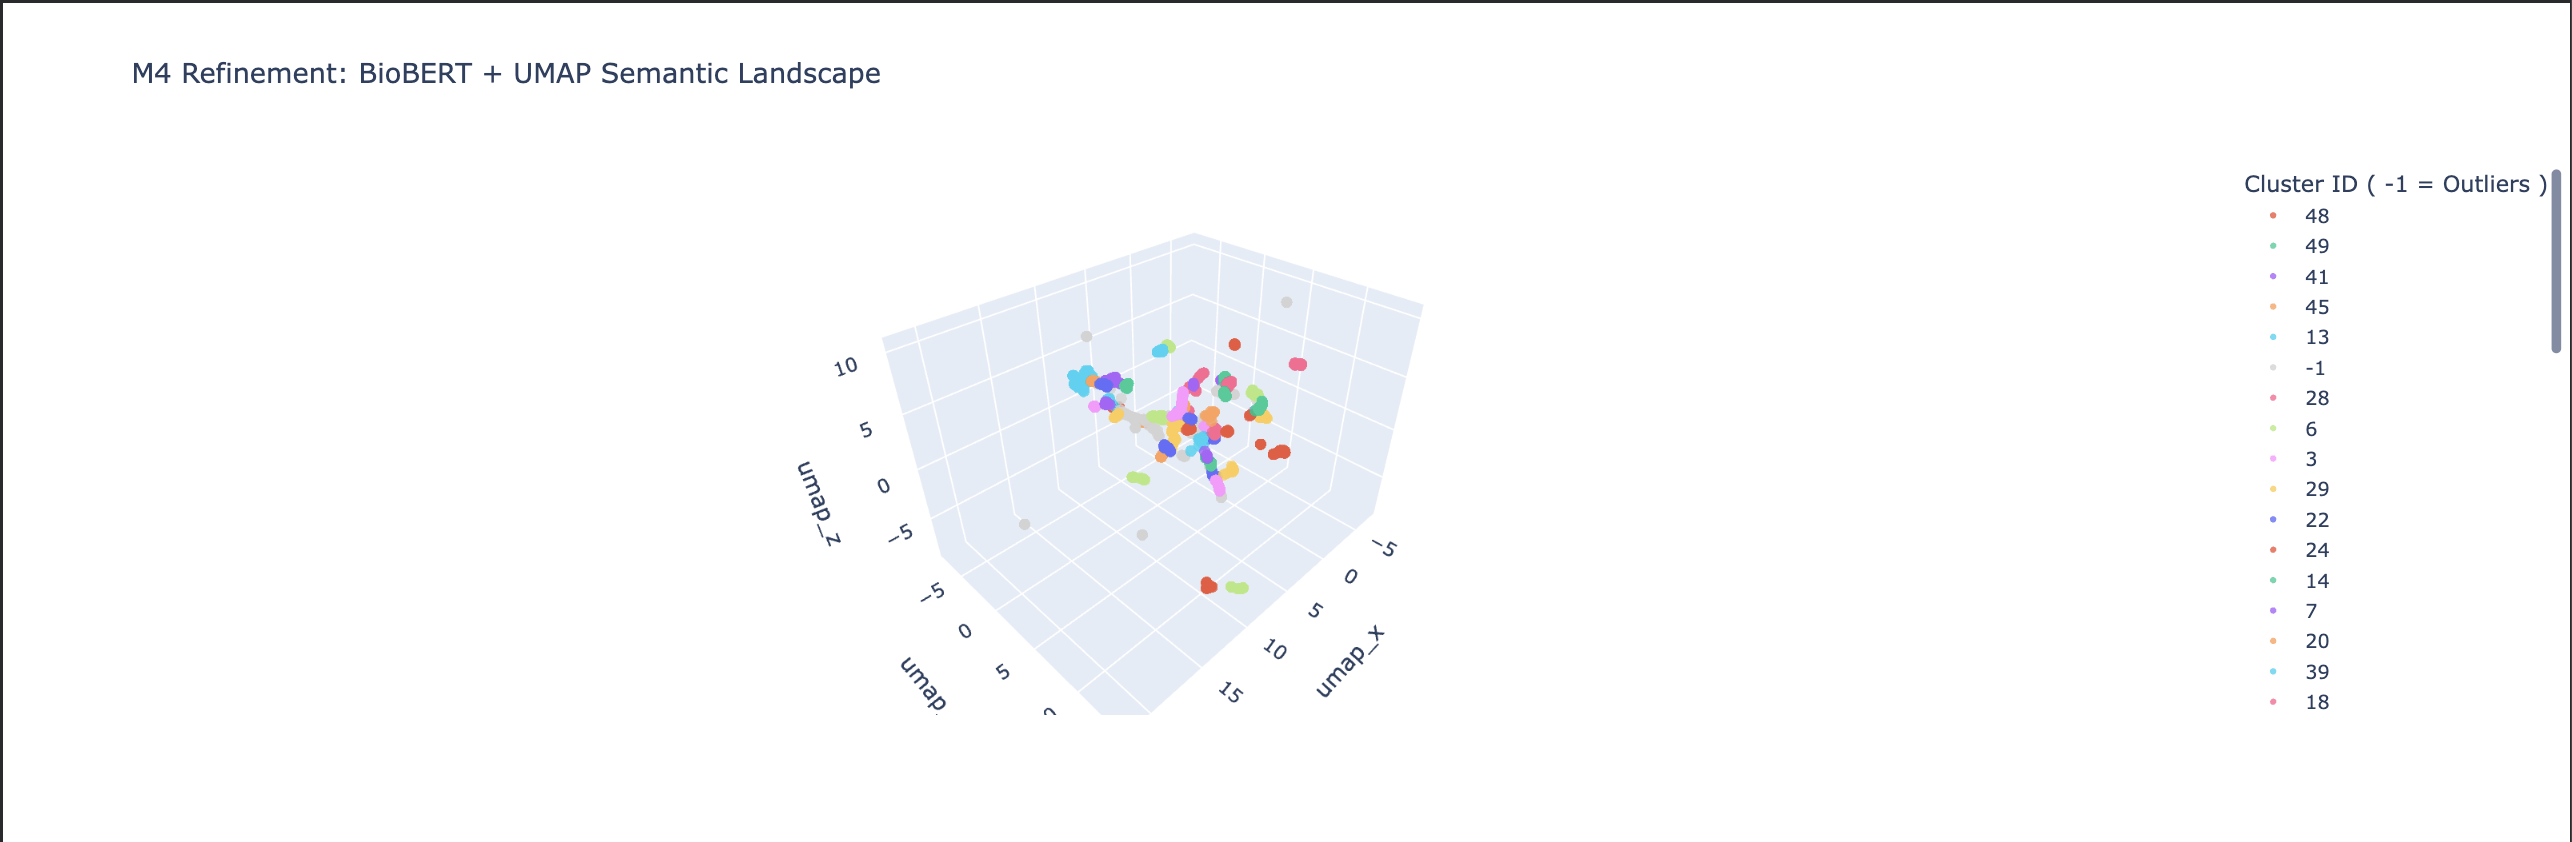

In [ ]:
def rotate_z(x, y, z, theta):
    w = x + 1j * y
    return np.real(w * np.exp(1j * theta)), np.imag(w * np.exp(1j * theta)), z

# 3. Create the animation frames
frames = []
for t in np.arange(0, 6.28, 0.1):
    xe, ye, ze = rotate_z(1.25, 1.25, 1.25, t)
    frames.append(dict(layout=dict(scene=dict(camera=dict(eye=dict(x=xe, y=ye, z=ze))))))

fig.frames = frames

# 4. Add the auto-play configuration
fig.update_layout(
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, dict(frame=dict(duration=50, redraw=True), fromcurrent=True, mode='immediate', loop=True)]
        )]
    )]
)

# 5. Export to HTML
fig.write_html("rotating_3d_plot.html", auto_play=True)

In [ ]:
crosstab_m4 = pd.crosstab(drugs['cluster_hdbscan'], drugs['category'])
overlap_clusters = crosstab_m4[(crosstab_m4['human'] > 0) & (crosstab_m4['veterinary'] > 0)]
overlap_clusters = overlap_clusters.drop(-1, errors='ignore')
print("--- 'One Health' Overlap Clusters (BioBERT + HDBSCAN) ---")
print(overlap_clusters)

--- 'One Health' Overlap Clusters (BioBERT + HDBSCAN) ---
category         human  veterinary
cluster_hdbscan                   
0                   25           1
5                   44           1
11                  19           1
13                 167           4
16                  13           6
18                  42           2
24                  30           1
30                  12           5
33                   7          13
35                  73           1
42                  37           1
46                  29           1
51                  20           1


The following output shows a closer examination of the medicine name and `condition_indication` of Cluster 29.

In [ ]:
target_cluster = 29

human_drugs = drugs[(drugs['cluster_hdbscan'] == target_cluster) & (drugs['category'] == 'human')]
print(f"\nHUMAN DRUGS ({len(human_drugs)} total):")
for index, row in human_drugs.head(5).iterrows():
    print(f" • {row['medicine_name']}: {str(row['condition_indication'])[:150]}...")

# 2. Print Veterinary Examples
vet_drugs = drugs[(drugs['cluster_hdbscan'] == target_cluster) & (drugs['category'] == 'veterinary')]
print(f"\nVETERINARY DRUGS ({len(vet_drugs)} total):")
for index, row in vet_drugs.head(5).iterrows():
    print(f" • {row['medicine_name']}: {str(row['condition_indication'])[:150]}...")


HUMAN DRUGS (47 total):
 • Rizmoic: Rizmoic is indicated for the treatment of opioid-induced constipation (OIC) in adult patients who have previously been treated with a laxative....
 • Revestive: Revestive is indicated for the treatment of patients aged 1 year and above with Short Bowel Syndrome (SBS). Patients should be stable following a peri...
 • Nyxoid: Nyxoid is intended for immediate administration as emergency therapy for known or suspected opioid overdose as manifested by respiratory and/or centra...
 • Sixmo: Sixmo is indicated for substitution treatment for opioid dependence in clinically stable adult patients who require no more than 8 mg/day of sublingua...
 • Pregabalin Zentiva: Neuropathic pain, , , 	Pregabalin Zentiva is indicated for the treatment of peripheral and central neuropathic pain in adults., , , Epilepsy, , , 	Pre...

VETERINARY DRUGS (0 total):


---
# Appendix: Integration with Prior Milestones (M3 to M4 Continuity)

To justify the architectural shift from a lexical TF-IDF pipeline (M3) to a semantic BioBERT pipeline (M4), several key Exploratory Data Analysis (EDA) and modeling metrics from M3 are referenced below.

### A. The Baseline Problem: Administrative Silos (M2)
Corporate Silos and Outlier Detection.

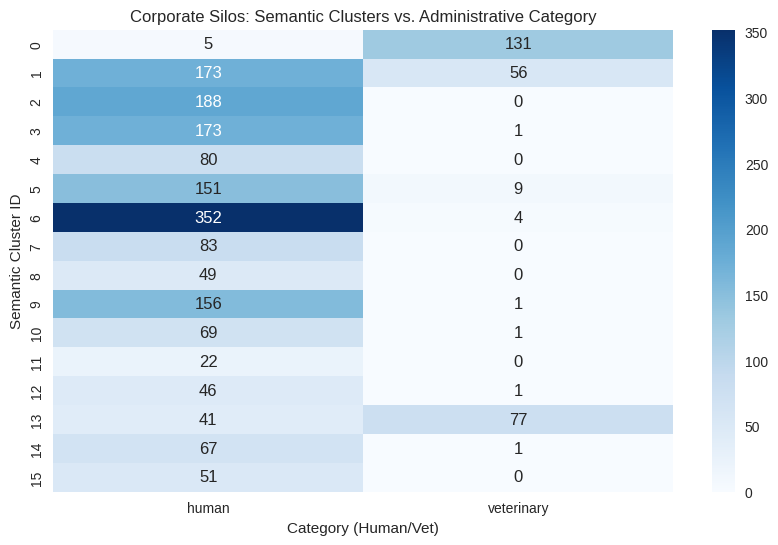

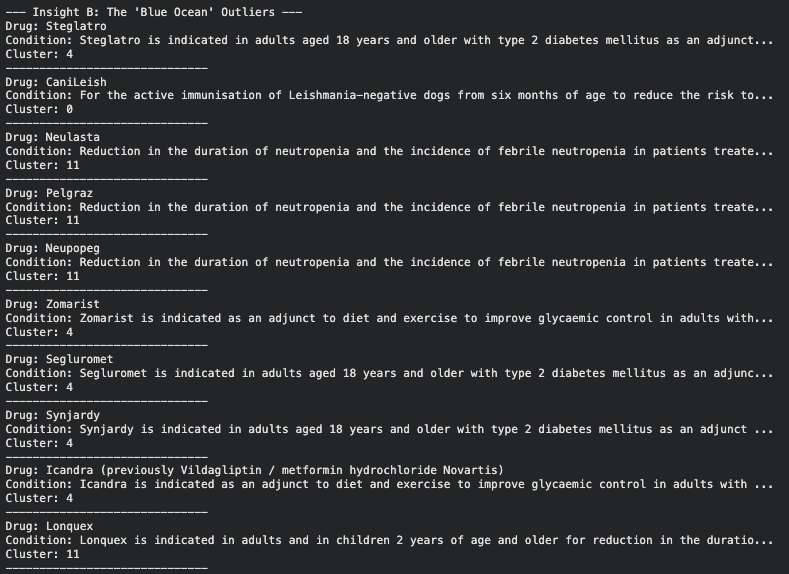

### B. Lexical Fragmentation, Top Keywords (M3 EDA)
Example:

Cluster 13: Dominated by exact terms like "dog", "pain", "inflammation", effectively isolating veterinary analgesics.

Cluster 1: Heavily weighted by terms like "flea", "infestation", but mixed confusingly with "influenza".

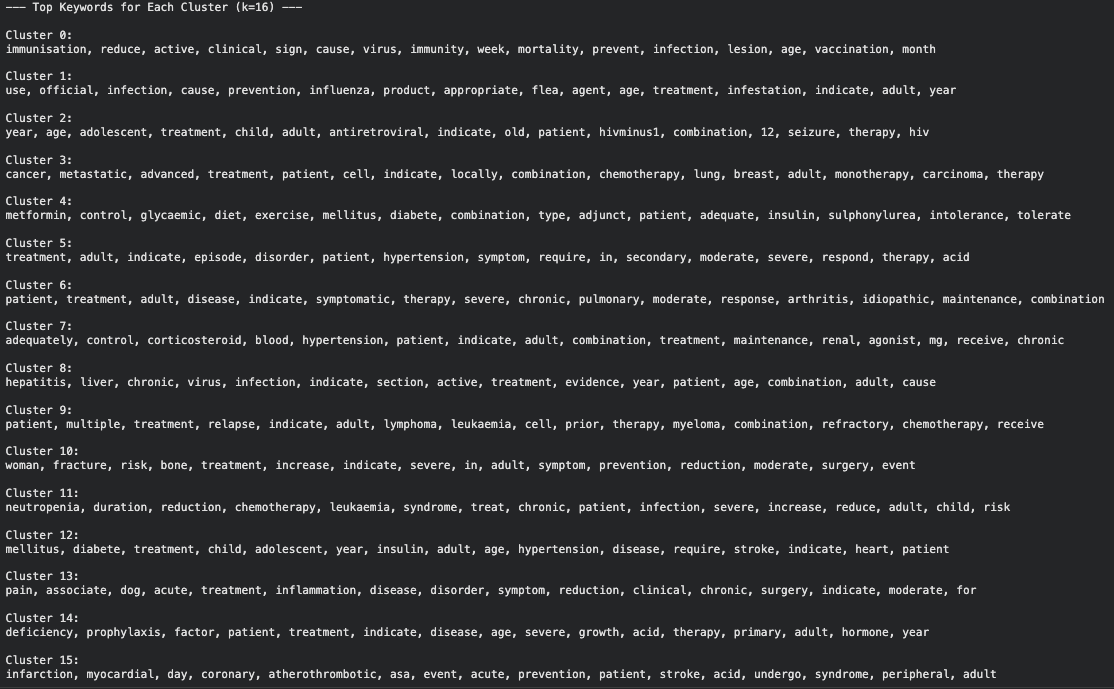


### B. M3 Baseline Model Limitations
The baseline M3 K-Means model yielded an ambiguous Silhouette Score and ideal K.
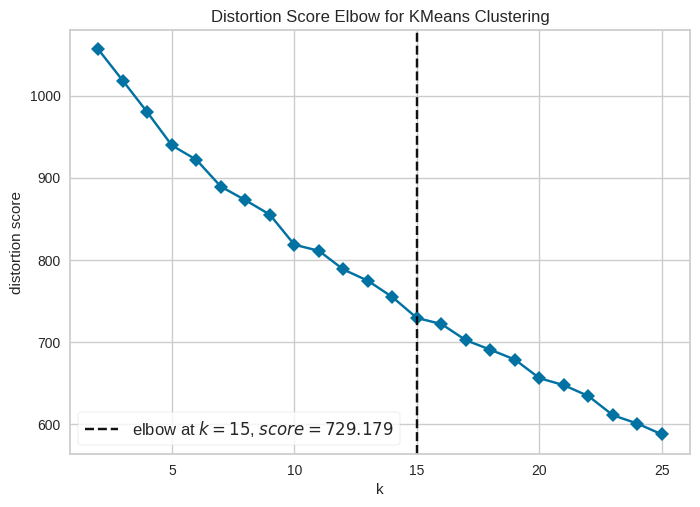

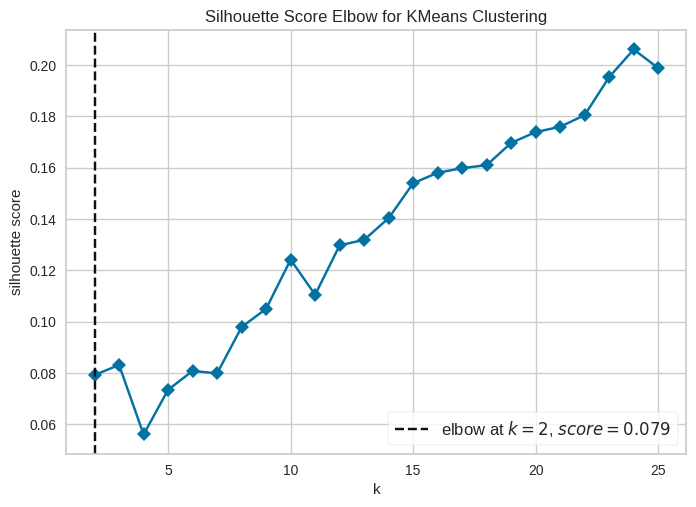

### C. M4 Preprocessing Validation (Sequence Length)
To ensure the raw medical text would not exceed BioBERT's token limits (typically 512 tokens), we validated the distribution of sequence lengths prior to embedding. As shown in Section 2 (EDA), the vast majority of indications fall well within this limit, allowing the Transformer to capture complete biological context without truncation.